In [2]:
import pandas as pd 

DF = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")

In [ ]:
1. MODEL cat인거만
2. Group by GAS 
3. N2 O2 H2 데이터프레임

각각
 H2                         N2                O2 
        |
        |ㅁㅁㅁ   ST 
 1bar   |ㅁㅁㅁㅁ  RD  
        |ㅁㅁㅁㅁㅁ QT
        | 
        |ㅁㅁㅁ   ST 
  5bar  ㅁㅁㅁㅁ  RD  
        |ㅁㅁㅁㅁㅁ QT
        |
        |ㅁㅁㅁ   ST 
        |ㅁㅁㅁㅁ  RD  
 15bar  |ㅁㅁㅁㅁㅁ QT
        |


SyntaxError: invalid syntax (139816005.py, line 1)

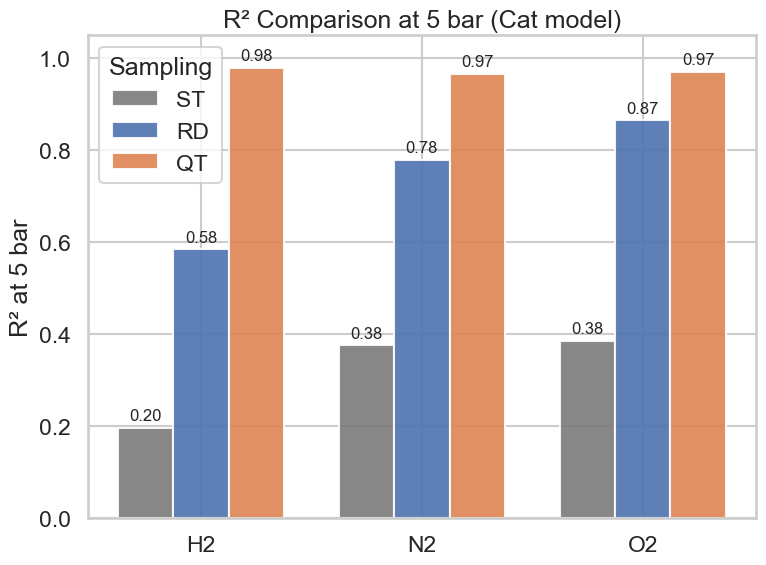

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 스타일
sns.set_theme(style="whitegrid", context="talk")

# 데이터 불러오기
df = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")

# MODEL cat만
df = df[df["MODEL"] == "cat"].copy()
df["SAMPLING"] = df["SAMPLING"].str.replace("_TRAIN_RATIO0.8", "")

# 샘플링 방식 매핑
label_map = {
    "random_struct__cat": "ST",
    "random_with_input__cat": "RD",
    "qt_then_rd__cat": "QT"
}
df["SAMPLING_SHORT"] = df["SAMPLING"].map(label_map)

# 색상 매핑
color_map = {"ST": "#7a7a7a", "RD": "#4C72B0", "QT": "#DD8452"}

# 대상 GAS
gases = ["H2", "N2", "O2"]
metric_col = "R2_MEAN_HIGH_5"  # 5 bar

# Figure
fig, ax = plt.subplots(figsize=(8,6))

x = np.arange(len(gases))  # H2, N2, O2 위치
width = 0.25

for i, samp in enumerate(["ST", "RD", "QT"]):
    r2_vals = []
    for gas in gases:
        subset = df[(df["GAS"] == gas) & (df["SAMPLING_SHORT"] == samp)]
        r2_vals.append(subset[metric_col].mean())
    
    bars = ax.bar(
        x + i*width, r2_vals, width,
        label=samp, color=color_map[samp], alpha=0.9
    )
    
    # 값 텍스트
    for bar, val in zip(bars, r2_vals):
        ax.text(
            bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=12
        )

# X축 세팅
ax.set_xticks(x + width)
ax.set_xticklabels(gases)
ax.set_ylim(0, 1.05)
ax.set_ylabel("R² at 5 bar")
ax.set_title("R² Comparison at 5 bar (Cat model)")

# 범례
ax.legend(title="Sampling")
plt.tight_layout()
plt.show()
